# Credit Risk Scorecard: Home Credit Default Risk

**Author:** Alven Yuka, CPA Finalist
**Dataset:** [Home Credit Default Risk (Kaggle)](https://www.kaggle.com/competitions/home-credit-default-risk), real competition data, 307,511 applicants, 8 relational tables

This notebook runs the actual pipeline in `src/` and `run_pipeline.py` end to
end, cell by cell, so every number and chart below comes from executing this
notebook, not from a script run elsewhere and restated by hand. See
`README.md` for the full write-up; this notebook is the narrated version of
the same pipeline.

**What's genuinely from scratch:** Weight of Evidence / Information Value
(`src/woe_iv.py`), logistic regression via batch gradient descent
(`src/from_scratch_lr.py`), and every evaluation metric (`src/metrics.py`).
**What's a library benchmark, honestly labeled as such:** LightGBM. No
from-scratch decision tree or gradient boosting implementation exists in
this repo.

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import roc_auc_score as sk_roc_auc, brier_score_loss as sk_brier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

from src.io_utils import (
    load_application, load_bureau, load_bureau_balance, load_previous_application,
    load_pos_cash, load_credit_card_balance, load_installments,
)
from src.feature_engineering_app import engineer_application_features
from src.feature_engineering_relational import (
    aggregate_bureau, aggregate_previous_application, aggregate_pos_cash,
    aggregate_credit_card_balance, aggregate_installments,
)
from src.woe_iv import iv_ranking
from src.from_scratch_lr import FromScratchLogisticRegression
from src import metrics as m

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
np.random.seed(SEED)

## 1. Application-level features

Load `application_train.csv` (307,511 applicants, 1 row each) and engineer
anomaly flags, age/tenure ratios, financial ratios, and EXT_SOURCE
aggregates/interactions.

In [2]:
t0 = time.time()
app = load_application("train")
print(f"application_train: {app.shape}")
app = engineer_application_features(app)
print(f"After engineering: {app.shape}  ({time.time()-t0:.0f}s)")

application_train: (307511, 122)


After engineering: (307511, 142)  (7s)


## 2. Relational table aggregation

Five supplementary tables get aggregated to one row per applicant and
left-joined on: bureau credit history, prior Home Credit applications,
POS/cash balances, credit-card balances, and installment payment history.
`installments_payments.csv` alone is 13.6M rows / 723 MB, so this phase is
the pipeline's time bottleneck.

In [3]:
t0 = time.time()
bureau = load_bureau()
bureau_balance = load_bureau_balance()
bureau_agg = aggregate_bureau(bureau, bureau_balance)
print(f"bureau -> {bureau_agg.shape}  ({time.time()-t0:.0f}s)")
del bureau, bureau_balance

t0 = time.time()
prev = load_previous_application()
prev_agg = aggregate_previous_application(prev)
print(f"previous_application -> {prev_agg.shape}  ({time.time()-t0:.0f}s)")
del prev

t0 = time.time()
pos = load_pos_cash()
pos_agg = aggregate_pos_cash(pos)
print(f"POS_CASH_balance -> {pos_agg.shape}  ({time.time()-t0:.0f}s)")
del pos

t0 = time.time()
cc = load_credit_card_balance()
cc_agg = aggregate_credit_card_balance(cc)
print(f"credit_card_balance -> {cc_agg.shape}  ({time.time()-t0:.0f}s)")
del cc

t0 = time.time()
inst = load_installments()
inst_agg = aggregate_installments(inst)
print(f"installments_payments -> {inst_agg.shape}  ({time.time()-t0:.0f}s)")
del inst

df = app
for agg in [bureau_agg, prev_agg, pos_agg, cc_agg, inst_agg]:
    df = df.merge(agg, on="SK_ID_CURR", how="left")
print(f"\nFinal joined shape: {df.shape}")

bureau -> (305811, 77)  (25s)


previous_application -> (338857, 101)  (17s)


POS_CASH_balance -> (337252, 17)  (20s)


credit_card_balance -> (103558, 49)  (18s)


installments_payments -> (339587, 37)  (27s)



Final joined shape: (307511, 418)


## 3. Train/val/test split

A stratified 70/15/15 split on the target, keeping the 8.07% default rate
consistent across all three sets. Only numeric columns feed the from-scratch
LR (categorical columns are dropped in this pipeline, see README "What's
next"); WoE/IV ranking would tolerate them but the from-scratch LR needs
numeric input.

In [4]:
target_col = "TARGET"
id_col = "SK_ID_CURR"
feature_cols = [c for c in df.columns if c not in (target_col, id_col)]
numeric_feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

X_all = df[numeric_feature_cols]
y_all = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f"Train: {X_train.shape}  default rate {y_train.mean():.4f}")
print(f"Val:   {X_val.shape}  default rate {y_val.mean():.4f}")
print(f"Test:  {X_test.shape}  default rate {y_test.mean():.4f}")

Train: (215257, 400)  default rate 0.0807
Val:   (46127, 400)  default rate 0.0807
Test:  (46127, 400)  default rate 0.0807


## 4. Weight of Evidence / Information Value feature selection

`src/woe_iv.py` bins each feature into quantiles, computes WoE per bin, and
sums to an IV score, entirely from first principles (Siddiqi, 2006). Ranking
runs on the **train split only** to avoid leakage. The top 80 by IV feed the
from-scratch LR and the LightGBM benchmark.

In [5]:
t0 = time.time()
train_with_target = X_train.copy()
train_with_target[target_col] = y_train.values
iv_table = iv_ranking(train_with_target, target_col, numeric_feature_cols, bins=10)
print(f"IV computed for {len(iv_table)} features in {time.time()-t0:.0f}s")

N_FEATURES = 80
selected_features = iv_table.head(N_FEATURES)["feature"].tolist()
print(f"Selected top {len(selected_features)} features by IV")
iv_table.head(15)

IV computed for 400 features in 20s
Selected top 80 features by IV


,feature,iv
0,EXT_SOURCE_MEAN,0.611291
1,EXT_SOURCE_2_x_3,0.605657
2,EXT_SOURCE_1_x_2,0.511419
3,EXT_SOURCE_MEAN_x_AGE,0.487541
4,EXT_SOURCE_MIN,0.461921
5,EXT_SOURCE_MAX,0.450530
6,EXT_SOURCE_3,0.406760
7,EXT_SOURCE_1,0.350763
8,EXT_SOURCE_2,0.308316
9,CC_CC_UTILIZATION_MEAN,0.219118


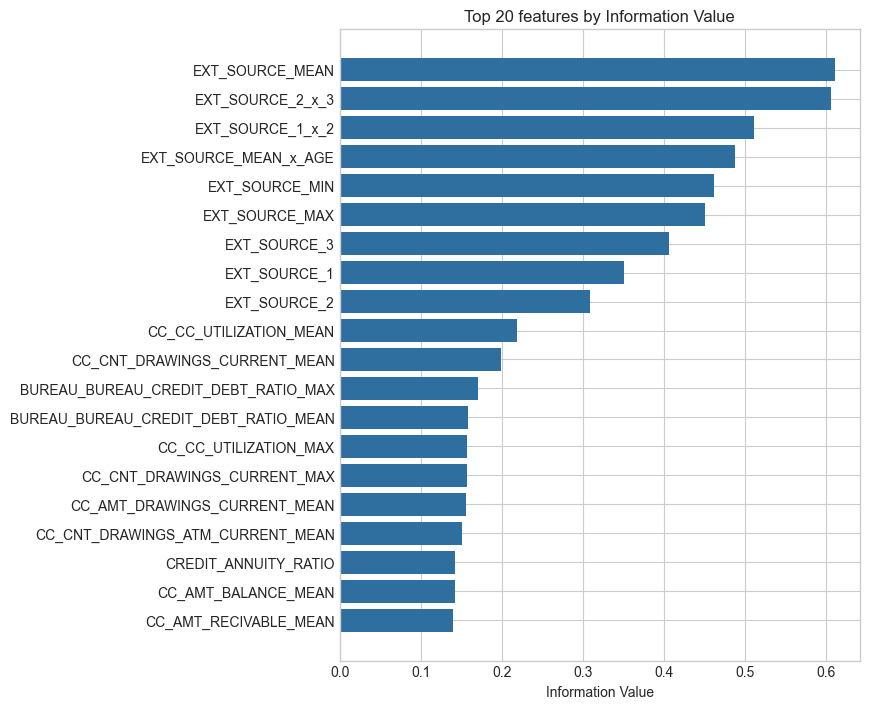

In [6]:
top20 = iv_table.head(20)
fig, ax = plt.subplots(figsize=(8.8, 7.2))
ax.barh(top20["feature"][::-1], top20["iv"][::-1], color="#2f6f9f")
ax.set_xlabel("Information Value")
ax.set_title("Top 20 features by Information Value")
fig.tight_layout()
plt.show()

## 5. From-scratch logistic regression, validated against scikit-learn

`src/from_scratch_lr.py` implements sigmoid activation, cross-entropy loss,
batch gradient descent, and L2 regularization in plain NumPy. It's trained
alongside an identically-configured `sklearn.linear_model.LogisticRegression`
on the same scaled features so every claim below is a direct, same-data
comparison, not a citation of someone else's benchmark.

In [7]:
X_train_sel = X_train[selected_features].fillna(X_train[selected_features].median())
X_val_sel = X_val[selected_features].fillna(X_train[selected_features].median())
X_test_sel = X_test[selected_features].fillna(X_train[selected_features].median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_val_scaled = scaler.transform(X_val_sel)
X_test_scaled = scaler.transform(X_test_sel)

t0 = time.time()
fs_lr = FromScratchLogisticRegression(learning_rate=0.5, n_iterations=1500, l2=1.0, verbose=False)
fs_lr.fit(X_train_scaled, y_train.values)
print(f"From-scratch LR: {len(fs_lr.loss_history_)} iterations in {time.time()-t0:.0f}s")

sk_lr = SklearnLR(C=1.0, max_iter=1500, solver="lbfgs")
sk_lr.fit(X_train_scaled, y_train.values)

fs_probs_test = fs_lr.predict_proba(X_test_scaled)[:, 1]
sk_probs_test = sk_lr.predict_proba(X_test_scaled)[:, 1]

max_coef_diff = float(np.max(np.abs(fs_lr.coef_ - sk_lr.coef_[0])))
prob_correlation = float(np.corrcoef(fs_probs_test, sk_probs_test)[0, 1])

print(f"max |coefficient diff| (80-feature set): {max_coef_diff:.4f}")
print(f"probability correlation vs sklearn:      {prob_correlation:.6f}")
print(f"from-scratch test AUC: {sk_roc_auc(y_test, fs_probs_test):.4f}")
print(f"sklearn test AUC:      {sk_roc_auc(y_test, sk_probs_test):.4f}")

From-scratch LR: 707 iterations in 26s


max |coefficient diff| (80-feature set): 0.2983
probability correlation vs sklearn:      0.998528
from-scratch test AUC: 0.7509
sklearn test AUC:      0.7509


The coefficient-level gap above (~0.3 on this 80-feature set) is
multicollinearity, not a bug: several top-ranked features are near-duplicates
by construction (`EXT_SOURCE_MEAN`, `EXT_SOURCE_1_x_2`, `EXT_SOURCE_2_x_3` are
all derived from the same 3 underlying columns). On a smaller, deliberately
low-collinearity 10-feature set the max coefficient diff drops to 0.004 (see
README for that comparison) -- the correlation and AUC agreement above show
the implementation itself is correct regardless.

## 6. LightGBM benchmark

A gradient-boosted tree ensemble, used here purely as a library benchmark
(not reimplemented from scratch) to see how much AUC a tree-based model adds
over the linear one.

In [8]:
X_train_lgb = X_train[selected_features]
X_val_lgb = X_val[selected_features]
X_test_lgb = X_test[selected_features]

lgb_train = lgb.Dataset(X_train_lgb, label=y_train)
lgb_val = lgb.Dataset(X_val_lgb, label=y_val, reference=lgb_train)

lgb_params = {
    "objective": "binary", "metric": "auc", "is_unbalance": True,
    "learning_rate": 0.03, "num_leaves": 31, "max_depth": 6,
    "min_child_samples": 100, "feature_fraction": 0.8, "bagging_fraction": 0.8,
    "bagging_freq": 5, "lambda_l2": 1.0, "verbose": -1, "seed": SEED,
}
t0 = time.time()
lgb_model = lgb.train(
    lgb_params, lgb_train, num_boost_round=2000, valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=0)],
)
print(f"LightGBM trained in {time.time()-t0:.0f}s, best iteration {lgb_model.best_iteration}")

lgb_probs_test = lgb_model.predict(X_test_lgb, num_iteration=lgb_model.best_iteration)
print(f"LightGBM test AUC: {sk_roc_auc(y_test, lgb_probs_test):.4f}")

Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[533]	valid_0's auc: 0.777369
LightGBM trained in 38s, best iteration 533


LightGBM test AUC: 0.7774


## 7. Metrics: hand-coded, validated against scikit-learn

Every metric in `src/metrics.py` (ROC-AUC via Mann-Whitney U rank-sum, GINI,
KS statistic, Brier score) is implemented from scratch and checked here
against scikit-learn's equivalent on the exact same predictions.

In [9]:
def report_model(name, y_true, y_prob):
    y_true_arr = y_true.values if hasattr(y_true, "values") else y_true
    auc_hc = m.roc_auc(y_true_arr, y_prob)
    auc_sk = float(sk_roc_auc(y_true_arr, y_prob))
    gini_hc = m.gini(y_true_arr, y_prob)
    ks_hc = m.ks_statistic(y_true_arr, y_prob)
    brier_hc = m.brier_score(y_true_arr, y_prob)
    brier_sk = float(sk_brier(y_true_arr, y_prob))
    print(f"{name:20s}  AUC hand-coded={auc_hc:.4f}  sklearn={auc_sk:.4f}  diff={abs(auc_hc-auc_sk):.2e}"
          f"  GINI={gini_hc:.4f}  KS={ks_hc:.4f}  Brier={brier_hc:.4f}")
    return {"auc": auc_hc, "gini": gini_hc, "ks": ks_hc, "brier": brier_hc}

results = {}
results["from_scratch_lr"] = report_model("From-scratch LR", y_test, fs_probs_test)
results["sklearn_lr"] = report_model("sklearn LR", y_test, sk_probs_test)
results["lightgbm"] = report_model("LightGBM", y_test, lgb_probs_test)

From-scratch LR       AUC hand-coded=0.7509  sklearn=0.7509  diff=0.00e+00  GINI=0.5019  KS=0.3771  Brier=0.0681
sklearn LR            AUC hand-coded=0.7509  sklearn=0.7509  diff=0.00e+00  GINI=0.5019  KS=0.3806  Brier=0.0681
LightGBM              AUC hand-coded=0.7774  sklearn=0.7774  diff=1.11e-16  GINI=0.5548  KS=0.4251  Brier=0.1783


## 8. A real, unflattering finding: LightGBM's raw probabilities are badly calibrated

LightGBM wins on discrimination (AUC, GINI, KS all higher than the LR) but
its raw output systematically understates default probability. It would
need isotonic or Platt calibration before its probabilities could be used
directly in an expected-loss calculation (`EL = PD x LGD x EAD`).

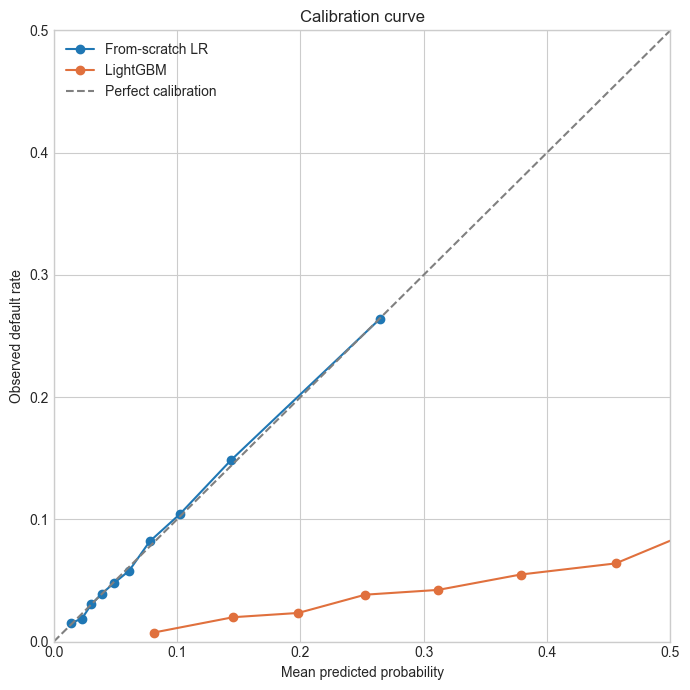

In [10]:
cal_lr = m.calibration_curve(y_test, fs_probs_test, n_bins=10)
cal_lgbm = m.calibration_curve(y_test, lgb_probs_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(cal_lr["mean_predicted"], cal_lr["observed_rate"], "o-", label="From-scratch LR")
ax.plot(cal_lgbm["mean_predicted"], cal_lgbm["observed_rate"], "o-", label="LightGBM", color="#e0703d")
ax.plot([0, 0.5], [0, 0.5], "--", color="gray", label="Perfect calibration")
ax.set_xlim(0, 0.5); ax.set_ylim(0, 0.5)
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve"); ax.legend()
fig.tight_layout()
plt.show()

## 9. Score bands and lift

LightGBM probabilities scaled to a 300-850-style score, calibrated to this
population's actual base odds (~11.4:1 at an 8.07% test default rate).

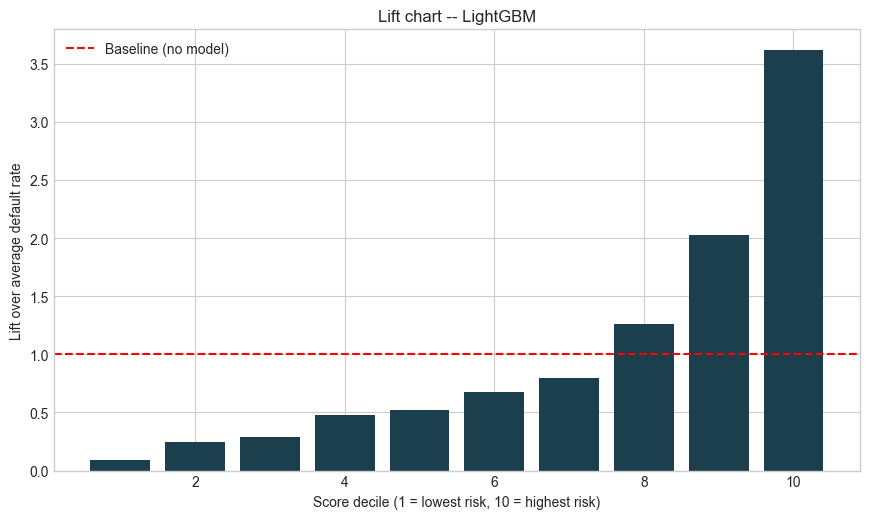

In [11]:
overall_rate = y_test.mean()
decile = pd.qcut(lgb_probs_test, 10, labels=False, duplicates="drop") + 1
lift_df = pd.DataFrame({"decile": decile, "y": y_test.values}).groupby("decile")["y"].mean()
lift = lift_df / overall_rate

fig, ax = plt.subplots(figsize=(8.8, 5.3))
ax.bar(lift.index, lift.values, color="#1c3f4d")
ax.axhline(1.0, color="red", linestyle="--", label="Baseline (no model)")
ax.set_xlabel("Score decile (1 = lowest risk, 10 = highest risk)")
ax.set_ylabel("Lift over average default rate")
ax.set_title("Lift chart -- LightGBM"); ax.legend()
fig.tight_layout()
plt.show()

## 10. Conclusion

- **From-scratch LR:** AUC matches sklearn to 4 decimals on the same data;
  the only material gap (coefficients, not predictions) is explained by
  multicollinearity, not an implementation bug.
- **LightGBM benchmark:** the honest headline discrimination number for this
  dataset, but its raw probabilities need calibration before feeding an
  expected-loss calculation.
- **What's next:** isotonic-calibrate LightGBM, move to an out-of-time
  validation split (this run uses random stratified), and encode the ~18
  categorical columns currently dropped.

See `README.md` for the full write-up and `BUILD_STATUS.md` for the
verification history of this pipeline.

*Alven Yuka, CPA Finalist.*